In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



===== Clinical Data ====
           Study ID   Patient ID Sample ID  AGE     Sex         Tumor Type  \
0  brain_cptac_2020  PT_CWD717Q0  7316-101    9    Male            Primary   
1  brain_cptac_2020  PT_5FR2YA6E  7316-109   11    Male            Primary   
2  brain_cptac_2020  PT_RM5S859Q  7316-111   12  Female            Primary   
3  brain_cptac_2020  PT_3X3MF8ZD  7316-114   30  Female  Second Malignancy   
4  brain_cptac_2020  PT_ZVV78QP5  7316-117    9    Male            Primary   

                                   Tumor Tissue Site  
0                                      Temporal Lobe  
1                         Cerebellum/Posterior Fossa  
2                                     Occipital Lobe  
3  Brain Stem- Pons,Brain Stem-Medulla,Spinal Cor...  
4                         Cerebellum/Posterior Fossa  

Clinical Numeric Shape
(218, 1)

===== Omics Data ====
     Unnamed: 0  cg07346310_mRNA  cg12315302_mRNA  cg06963844_mRNA  \
0  TCGA-CS-4938         0.950402         0.876169

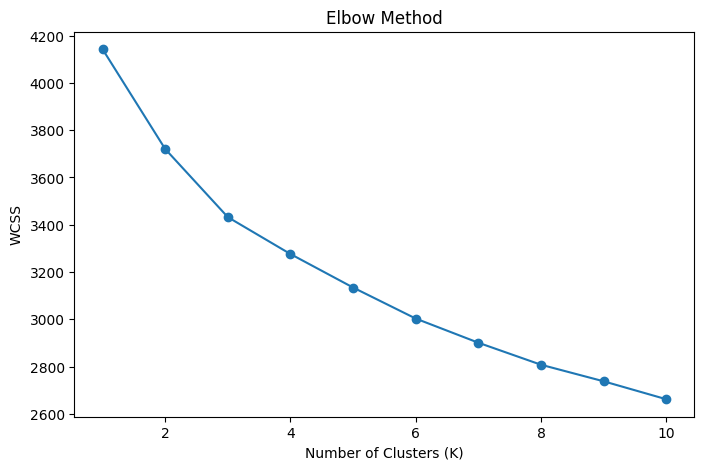


===== Cluster Result ====
   AGE        PC1       PC2       PC3        PC4       PC5       PC6  \
0    9   9.005797 -3.480872 -8.695592  -7.002463  4.101651  3.629249   
1   11 -30.908266  1.763682  3.919823  -0.630253 -3.420717  4.314613   
2   12   1.135481 -2.097326 -7.632384  -6.876607  1.887202  4.459859   
3   30  15.928896  3.874501  0.214825  -5.693162 -3.710756  6.653509   
4    9   1.996726  0.296350  1.905817 -14.052628 -0.743211 -1.957647   

        PC7       PC8       PC9      PC10     area    perimeter  circularity  \
0  2.913880 -4.755125 -0.559047  2.992971  65025.0  1020.000000     0.785398   
1  2.913702 -0.327686  1.011671  0.043286  41183.5   834.080296     0.743905   
2  1.376554 -4.228808  0.077716 -0.202877  45790.5   976.080297     0.603968   
3 -4.862150  2.423801 -1.352069 -1.259884  41487.0   775.636645     0.866573   
4 -0.544385 -2.364407  1.114946 -0.291454  39760.5   797.653889     0.785295   

   mean_intensity  std_intensity    contrast  homogeneity  

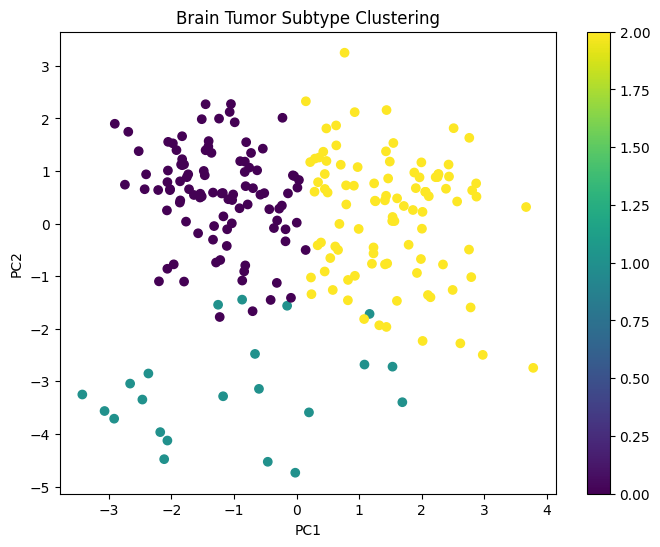


===== Cluster Summary ====
              AGE       PC1       PC2       PC3       PC4       PC5       PC6  \
Cluster                                                                         
0        7.686869 -1.192373 -0.915515  0.128498 -0.757428 -1.799213  0.901325   
1        7.409091 -0.876702 -1.942611  0.531090 -1.331689  1.190935  0.564108   
2        8.092784  0.621974  0.125294 -1.168869 -0.785872  0.021712  0.571224   

              PC7       PC8       PC9      PC10          area    perimeter  \
Cluster                                                                      
0       -0.402326  0.931869  0.320858  0.300309  36991.989899   788.095450   
1        0.036090  0.180253 -0.103419 -0.525994  31784.909091  2315.690618   
2        0.652766 -0.004977 -0.808365  0.199247  40752.195876   889.925671   

         circularity  mean_intensity  std_intensity    contrast  homogeneity  \
Cluster                                                                        
0           0.7

In [6]:
# =========================================================
# Brain Tumor Subtype Clustering Project
# Final Version
# Clinical + Omics + MRI 기반 K-Means Clustering
# =========================================================

# =========================================================
# 1. 라이브러리 import
# =========================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Add seaborn import

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from skimage.feature import graycomatrix
from skimage.feature import graycoprops

# =========================================================
# 2. 데이터 경로 설정
# (경로는 이미 이전 셀에서 설정되었으므로 이 부분은 주석 처리합니다)
# =========================================================

# Clinical 데이터
# clinical_path = "Clinical_Data.xlsx"

# Omics 데이터
# omics_path = "Omics_Data.csv"

# MRI 이미지 폴더
# mri_folder = "MRI_images"

# =========================================================
# 3. Clinical Data 불러오기
# =========================================================

clinical = pd.read_excel(clinical_path)

print("\n===== Clinical Data ====")
print(clinical.head())

# 숫자형 변수만 선택
clinical_numeric = clinical.select_dtypes(
                        include=np.number)

# 결측치 처리
clinical_numeric = clinical_numeric.fillna(
                        clinical_numeric.mean())

print("\nClinical Numeric Shape")
print(clinical_numeric.shape)

# =========================================================
# 4. Omics Data 불러오기
# =========================================================

omics = pd.read_csv(
            omics_path,
            sep="\t")

print("\n===== Omics Data ====")
print(omics.head())

# 첫 컬럼(ID 등) 제외
omics_numeric = omics.iloc[:,1:]

# 숫자형만 선택
omics_numeric = omics_numeric.select_dtypes(
                    include=np.number)

# 결측치 처리
omics_numeric = omics_numeric.fillna(
                    omics_numeric.mean())

# 모든 값이 NaN인 열 제거 (추가된 부분)
omics_numeric = omics_numeric.dropna(axis=1, how='all')

print("\nOmics Numeric Shape")
print(omics_numeric.shape)

# =========================================================
# 5. Omics Scaling
# =========================================================

omics_scaler = StandardScaler()

omics_scaled = omics_scaler.fit_transform(
                    omics_numeric)

print("\nOmics Scaling 완료")

# =========================================================
# 6. PCA 차원 축소
# =========================================================

# 고차원 유전자 데이터 축소

pca = PCA(n_components=10)

omics_pca = pca.fit_transform(
                omics_scaled)

omics_pca = pd.DataFrame(
                omics_pca,
                columns=[f"PC{i+1}"
                         for i in range(10)])

print("\n===== PCA 완료 ====")
print(omics_pca.head())

# 설명 분산 출력
print("\nExplained Variance Ratio")
print(pca.explained_variance_ratio_)

# =========================================================
# 7. MRI Feature Extraction
# =========================================================

print("\n===== MRI Feature Extraction 시작 ===плы")

mri_features = []

# 모든 이미지 반복
for file in os.listdir(mri_folder):

    path = os.path.join(
                mri_folder,
                file)

    # grayscale 읽기
    img = cv2.imread(path, 0)

    # 이미지 없는 경우 skip
    if img is None:
        continue

    # -----------------------------------------------------
    # Resize
    # -----------------------------------------------------

    img = cv2.resize(
            img,
            (256,256))

    # -----------------------------------------------------
    # Normalize
    # -----------------------------------------------------

    img = img / 255.0

    # -----------------------------------------------------
    # Segmentation
    # -----------------------------------------------------

    _, thresh = cv2.threshold(

        (img*255).astype(np.uint8),

        45,

        255,

        cv2.THRESH_BINARY

    )

    # contour 찾기
    contours, _ = cv2.findContours(

        thresh,

        cv2.RETR_EXTERNAL,

        cv2.CHAIN_APPROX_SIMPLE

    )

    # -----------------------------------------------------
    # Shape Feature
    # -----------------------------------------------------

    if len(contours) > 0:

        c = max(
                contours,
                key=cv2.contourArea)

        # 종양 면적
        area = cv2.contourArea(c)

        # 종양 둘레
        perimeter = cv2.arcLength(
                        c,
                        True)

        # 원형도
        circularity = (

            4 * np.pi * area

        ) / (perimeter**2 + 1e-5)

    else:

        area = 0
        perimeter = 0
        circularity = 0

    # -----------------------------------------------------
    # Intensity Feature
    # -----------------------------------------------------

    mean_intensity = np.mean(img)

    std_intensity = np.std(img)

    # -----------------------------------------------------
    # Texture Feature
    # -----------------------------------------------------

    glcm = graycomatrix(

        (img*255).astype(np.uint8),

        [1],

        [0],

        256,

        symmetric=True,

        normed=True

    )

    contrast = graycoprops(
                    glcm,
                    'contrast')[0,0]

    homogeneity = graycoprops(
                        glcm,
                        'homogeneity')[0,0]

    energy = graycoprops(
                    glcm,
                    'energy')[0,0]

    # -----------------------------------------------------
    # Feature 저장
    # -----------------------------------------------------

    mri_features.append([

        file,

        area,

        perimeter,

        circularity,

        mean_intensity,

        std_intensity,

        contrast,

        homogeneity,

        energy

    ])

# MRI feature dataframe 생성
mri_features = pd.DataFrame(

    mri_features,

    columns=[

        "image",

        "area",

        "perimeter",

        "circularity",

        "mean_intensity",

        "std_intensity",

        "contrast",

        "homogeneity",

        "energy"

    ]
)

print("\n===== MRI Feature 완료 ====")
print(mri_features.head())

# =========================================================
# 8. 데이터 통합
# =========================================================

# 실제 연구에서는
# Patient_ID 기준 merge 필요

# 여기서는 데이터 개수 맞춤

min_len = min(

    len(clinical_numeric),

    len(omics_pca),

    len(mri_features)

)

clinical_numeric = clinical_numeric.iloc[:min_len]

omics_pca = omics_pca.iloc[:min_len]

mri_numeric = mri_features.iloc[:min_len,1:]

# 최종 feature table
final_data = pd.concat([

    clinical_numeric.reset_index(drop=True),

    omics_pca.reset_index(drop=True),

    mri_numeric.reset_index(drop=True)

], axis=1)

print("\n===== Final Data ====")
print(final_data.head())

print("\nFinal Data Shape")
print(final_data.shape)

# =========================================================
# 9. 최종 Scaling
# =========================================================

final_scaler = StandardScaler()

scaled_data = final_scaler.fit_transform(
                    final_data)

print("\nFinal Scaling 완료")

# =========================================================
# 10. Elbow Method
# =========================================================

print("\n===== Elbow Method ====")

wcss = []

for k in range(1,11):

    km = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    km.fit(scaled_data)

    wcss.append(km.inertia_)

# Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(

    range(1,11),

    wcss,

    marker='o'

)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# =========================================================
# 11. K-Means Clustering
# =========================================================

# Elbow 결과 기반으로
# 예시 K=3 사용

optimal_k = 3

kmeans = KMeans(

    n_clusters=optimal_k,

    random_state=42,

    n_init=10

)

clusters = kmeans.fit_predict(
                scaled_data)

# cluster 저장
final_data["Cluster"] = clusters

print("\n===== Cluster Result ====")
print(final_data.head())

# =========================================================
# 12. Silhouette Score
# =========================================================

score = silhouette_score(

            scaled_data,

            clusters

)

print("\nSilhouette Score")
print(score)

# =========================================================
# 13. PCA Visualization
# =========================================================

pca_vis = PCA(n_components=2)

pca_result = pca_vis.fit_transform(
                    scaled_data)

plt.figure(figsize=(8,6))

scatter = plt.scatter(

    pca_result[:,0],

    pca_result[:,1],

    c=clusters

)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Brain Tumor Subtype Clustering")

plt.colorbar(scatter)

plt.show()

# =========================================================
# 14. Cluster별 특징 분석
# =========================================================

cluster_summary = final_data.groupby(
                        "Cluster").mean()

print("\n===== Cluster Summary ====")
print(cluster_summary)

# =========================================================
# 15. Cluster별 데이터 개수
# =========================================================

print("\n===== Cluster Count ====")

print(
    final_data["Cluster"].value_counts()
)

# =========================================================
# 16. 결과 저장
# =========================================================

final_data.to_csv(

    "Brain_Tumor_Subtype_Result.csv",

    index=False

)

print("\n===== 저장 완료 ====")
print("Brain_Tumor_Subtype_Result.csv 저장됨")


### Cluster별 특징 시각화 (Heatmap)

### 한글 폰트 설정 (Heatmap 한글 깨짐 해결)

In [8]:
# 나눔폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 런타임 재시작 필요 메시지 출력
print("----------------------------------------------------------------------------------------------------------------------------------------------")
print("한글 폰트 설치가 완료되었습니다. 변경 사항을 적용하려면 '런타임 > 런타임 다시 시작'을 클릭하여 런타임을 재시작한 후, 이전 셀과 이 셀을 다시 실행해주세요.")
print("----------------------------------------------------------------------------------------------------------------------------------------------")

# matplotlib 폰트 설정 (런타임 재시작 후 이 셀을 다시 실행해야 적용됨)
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("Matplotlib에 NanumBarunGothic 폰트가 설정되었습니다.")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (25.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and direc

In [9]:
# matplotlib 폰트 설정 (런타임 재시작 후 이 셀을 다시 실행해야 적용됨)
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("Matplotlib에 NanumBarunGothic 폰트가 설정되었습니다. 이제 히트맵 시각화 셀을 다시 실행해주세요.")

Matplotlib에 NanumBarunGothic 폰트가 설정되었습니다. 이제 히트맵 시각화 셀을 다시 실행해주세요.


In [12]:
# Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# NanumBarunGothic 폰트 경로 찾기
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
nanum_font_path = None
for font_path in font_list:
    if 'NanumBarunGothic' in font_path:
        nanum_font_path = font_path
        break

if nanum_font_path:
    fm.fontManager.addfont(nanum_font_path)
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지
    print("Matplotlib에 'NanumBarunGothic' 폰트가 성공적으로 설정되었습니다. 이제 히트맵 시각화 셀을 다시 실행해주세요.")
else:
    print("NanumBarunGothic 폰트를 찾을 수 없습니다. 폰트 설치가 제대로 되었는지 확인해주세요.")


Matplotlib에 'NanumBarunGothic' 폰트가 성공적으로 설정되었습니다. 이제 히트맵 시각화 셀을 다시 실행해주세요.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


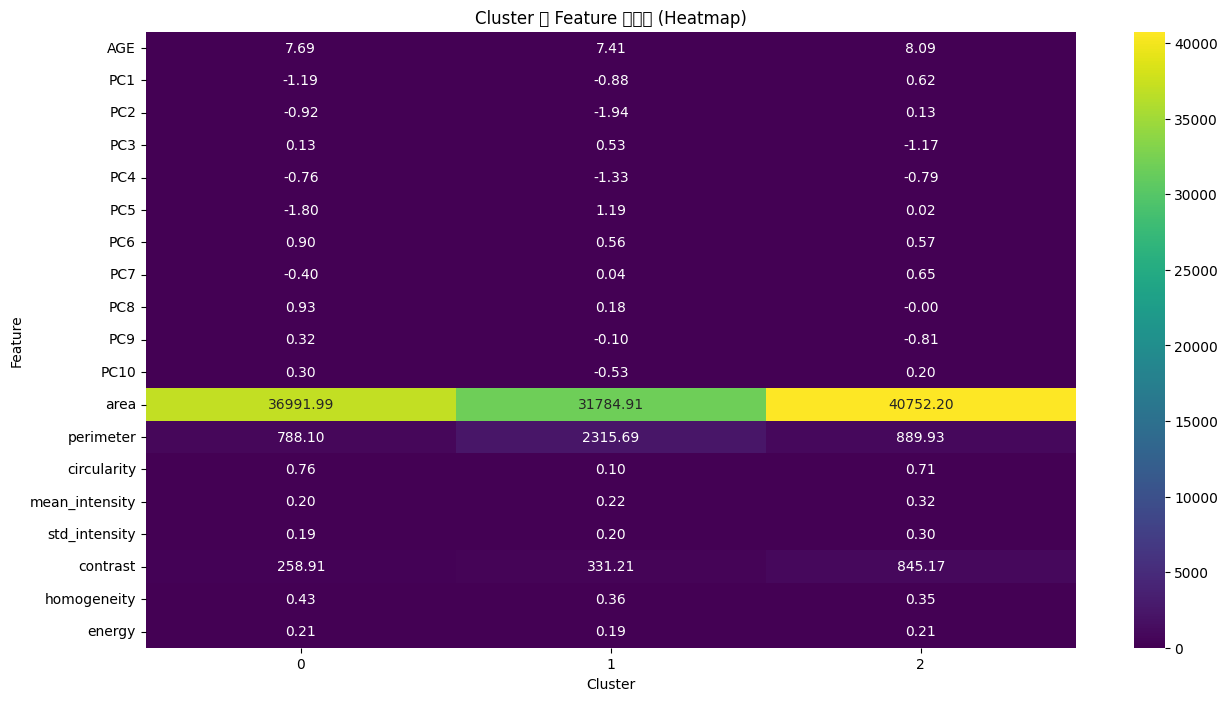

In [10]:
plt.figure(figsize=(15, 8))
sns.heatmap(cluster_summary.T, annot=True, cmap='viridis', fmt=".2f")
plt.title('Cluster 별 Feature 평균값 (Heatmap)')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.show()

In [2]:
# Update data paths to Google Drive locations
clinical_path = "/content/drive/MyDrive/융합정보의학 프로젝트/Data/1. Clinical Data/Clinical_Data.xlsx"
omics_path = "/content/drive/MyDrive/융합정보의학 프로젝트/Data/2. Omics Data/Omics_Data.csv"
mri_folder = "/content/drive/MyDrive/융합정보의학 프로젝트/Data/3. Image Data"